# DenseAM force-matching on 12×12 MNIST 0/1

This notebook is the §13.3 continuation of [`latent_dam_2d_toy_jax_v2.ipynb`](latent_dam_2d_toy_jax_v2.ipynb) on the MNIST setup proposed in `notes/latent_dam_force_matching.pdf`. It restricts attention to the **categorical DenseAM** model (the log-sum-exp prototype free energy) — none of the polynomial / binary-RBM / MLP baselines from the 2D notebook are included.

**What is kept from the 2D notebook.** The mathematical setup is unchanged. The forward Ornstein–Uhlenbeck corruption $x_t = a_t x_0 + \\sigma_t \\epsilon$ with $a_t = e^{-t}$ and $\\sigma_t^2 = k_BT(1 - a_t^2)$ defines the denoising target $f^\\star = -(x_t - a_t x_0)/\\sigma_t^2$. The DenseAM free energy is
$$\\log p_\\theta(x, t) \\;=\\; -\\frac{1}{2\\sigma_t^2}\\lVert x\\rVert^2 \\;+\\; \\log \\sum_{a=1}^{K}\\exp\\!\\left[\\frac{a_t\\, x^\\top c_a}{\\sigma_t^2} - \\frac{a_t^2\\lVert c_a\\rVert^2}{2\\sigma_t^2} + b_a\\right] + \\text{const},$$
with trainable prototypes $c_a \\in \\mathbb R^d$ and biases $b_a$. The force is the responsibility-weighted attraction $f_\\theta = (1/\\sigma_t^2)\\sum_a r_a(a_t c_a - x)$ with $r_a = \\mathrm{softmax}_a[\\,a_t x^\\top c_a/\\sigma_t^2 - a_t^2 \\lVert c_a\\rVert^2/(2\\sigma_t^2) + b_a\\,]$. The training protocol is unchanged: denoising force matching, per-slice from high noise to low noise, warm-started from the previous slice (§8 of the note).

**What is different from the 2D version.**
1. **Visible dimension** $d = 144$ instead of $d = 2$. Prototypes are stored 12×12 images.
2. **Drift-aware prototypes.** In 2D we used $\\tfrac12\\lVert x - c_a\\rVert^2/\\sigma_t^2$ in the logits, which mixes the noised data variance into the Gaussian quadratic. In high-$d$ the OU drift $a_t = e^{-t}$ is no longer negligible across the schedule, so we use the *exact* identity from eq. (5) of the note — the prototypes are matched to clean memories $\\xi_\\mu$ and the logits use $a_t x^\\top c_a / \\sigma_t^2 - a_t^2 \\lVert c_a\\rVert^2/(2\\sigma_t^2)$. At $a_t = 1$ (the variance-exploding limit) this reduces to the 2D form.
3. **Data**: 12×12 downsampled MNIST restricted to digits 0/1, as specified in §13.3 of the note.
4. **$K$-sweep diagnostics**: a small sweep over the number of prototypes $K \\in \\{16, 32, 64, 128\\}$ probes the memorization-vs-generalization phase that §9.2/§12.3 of the note flags as the central risk.
5. **Memorization diagnostic**: mean nearest-neighbour distance from generated samples to the training set, both in pixel space and to the nearest prototype. The note (§13.3) lists this and the spurious-state rate as the two key DenseAM evaluation metrics.

The interpretation checklist at the bottom of the 2D notebook (gradient check, sample quality, score-error, hidden-time-scale) applies here too, except that the binary-RBM hidden-time-scale sweep is no longer relevant — DenseAM has only one hidden time scale (the categorical posterior).

In [1]:
import math
import time
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import random
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())

JAX version: 0.4.33
Devices: [CudaDevice(id=0)]


## Configuration

Defaults are calibrated for `RESEARCH_MODE = False` to run in a few minutes on a single GPU; `RESEARCH_MODE = True` widens every knob for cleaner figures.

The time grid is denser than the 2D toy because the higher dimensionality means the score-error landscape is more curved in $t$: with too-coarse a grid the warm start jumps too far between slices and the optimizer has to relearn rather than refine.

In [2]:
# ----------------------------------------------------------------------
# Experiment knobs.
# ----------------------------------------------------------------------
SEED = 0
RESEARCH_MODE = False

# Dataset: IMG_SIDE x IMG_SIDE downsampled MNIST, restricted to digits in DIGITS.
# The note's §13.3 uses IMG_SIDE = 12; supported values are integer downsamples of 28
# (i.e. 28, 14, 12, 7, 4 — see downsample_avg below for the rule).
IMG_SIDE = 28
IMG_DIM = IMG_SIDE * IMG_SIDE
DIGITS = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)

if RESEARCH_MODE:
    N_TRAIN = 4000
    N_TIME = 24
    STEPS_PER_TIME = 500
    BATCH_SIZE = 256
    N_REVERSE_STEPS = 400
    N_SAMPLES = 64
else:
    N_TRAIN = 2000
    N_TIME = 16
    STEPS_PER_TIME = 250
    BATCH_SIZE = 128
    N_REVERSE_STEPS = 250
    N_SAMPLES = 64

# Physical / noising parameters.
kBT = 1.0
TAU = 3.0
T_MIN = 2e-2
TIME_GRID = jnp.linspace(T_MIN, TAU, N_TIME)

# Default DenseAM size; the K-sweep cell overrides this.
K_DEFAULT = 64

# Optimisation.
LR_CAT = 3e-3
GRAD_CLIP = 5.0
REG_SCALE = 1e-6

key = random.PRNGKey(SEED)
print(f"config: IMG_SIDE={IMG_SIDE} (d={IMG_DIM}) | TAU={TAU} | N_TIME={N_TIME} "
      f"| STEPS_PER_TIME={STEPS_PER_TIME} | K_DEFAULT={K_DEFAULT}")

config: IMG_SIDE=28 (d=784) | TAU=3.0 | N_TIME=16 | STEPS_PER_TIME=250 | K_DEFAULT=64


2026-05-19 21:24:52.089045: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Minimal PyTree Adam

Lifted verbatim from the 2D notebook so the file stays self-contained.

In [3]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum(jnp.sum(jnp.square(x)) for x in leaves)


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params),
            "t": jnp.array(0, dtype=jnp.int32)}


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g,
                                state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g),
                                state["v"], grads)
    m_hat = jax.tree_util.tree_map(lambda m: m / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda v: v / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat)
    return params, {"m": m, "v": v, "t": t}

## Data: `IMG_SIDE × IMG_SIDE` downsampled MNIST, restricted to `DIGITS`

The note's §13.3 specifies `IMG_SIDE = 12` and `DIGITS = (0, 1)`; both are knobs in the config cell above. The downsampler picks the largest integer factor `k` with `IMG_SIDE * k ≤ 28`, central-crops to `IMG_SIDE * k`, then mean-pools by `k`. So `IMG_SIDE = 28` is full-resolution MNIST, `IMG_SIDE = 14` is a clean 2× downsample, `IMG_SIDE = 12` matches the note, and `IMG_SIDE = 7` is a 4× downsample. The visible dimension `IMG_DIM = IMG_SIDE²` is recomputed automatically.

Pixels are mapped to $[-1, 1]$ so that the OU prior $\mathcal N(0, k_BT I)$ at $t = \tau$ has roughly the right scale. This is the implicit assumption behind using $k_BT = 1$ throughout — if you change the data normalisation, scale $k_BT$ accordingly.

2026-05-19 21:24:52.311580: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779225892.322793   15091 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779225892.326094   15091 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


train_data: (2000, 784) | image: 28x28 (d=784) | mean/std = -0.736 / 0.619 | per-class counts: {0: 201, 1: 211, 2: 184, 3: 196, 4: 182, 5: 197, 6: 214, 7: 216, 8: 199, 9: 200}


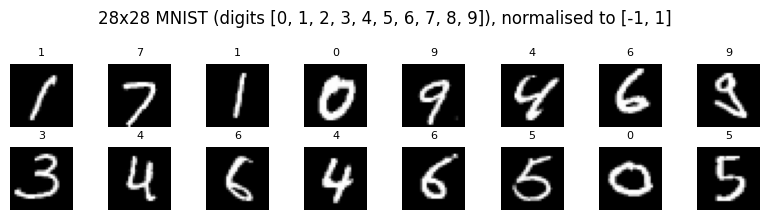

In [4]:
def _load_mnist_raw():
    """Load raw MNIST training data as (n, 28, 28) uint8 and (n,) labels.

    Tries tensorflow.keras.datasets first (works fully offline once cached),
    then sklearn.fetch_openml as a fallback.
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), _ = mnist.load_data()
        return np.asarray(x_train, dtype=np.uint8), np.asarray(y_train, dtype=np.int32)
    except Exception as exc_tf:
        print("keras.datasets.mnist failed:", exc_tf)
        from sklearn.datasets import fetch_openml
        d = fetch_openml("mnist_784", version=1, as_frame=False, cache=True)
        x = np.asarray(d.data, dtype=np.uint8).reshape(-1, 28, 28)
        y = np.asarray(d.target, dtype=np.int32)
        return x[:60000], y[:60000]


def downsample_avg(x_28, out_side):
    """Downsample (n, 28, 28) uint8 -> (n, out_side, out_side) float32 in [0, 1].

    Strategy: pick the largest integer factor k such that out_side * k <= 28,
    central-crop to (out_side * k, out_side * k), then mean-pool kxk. This keeps
    a clean prototype geometry at every supported resolution:
        28 -> k=1, no crop, no pool          (full resolution)
        14 -> k=2, no crop, 2x2 pool
        12 -> k=2, crop to 24, 2x2 pool      (the original §13.3 setting)
         7 -> k=4, no crop, 4x4 pool
         4 -> k=7, no crop, 7x7 pool

    Out-of-range out_side values are rejected explicitly.
    """
    if out_side < 1 or out_side > 28:
        raise ValueError(f"out_side must be in [1, 28]; got {out_side}")
    k = 28 // out_side
    if k < 1:
        raise ValueError(f"out_side={out_side} cannot fit into 28 with any integer factor")
    cropped_side = out_side * k
    pad = (28 - cropped_side) // 2
    x = x_28[:, pad:pad + cropped_side, pad:pad + cropped_side].astype(np.float32) / 255.0
    if k > 1:
        x = x.reshape(-1, out_side, k, out_side, k).mean(axis=(2, 4))
    return x


def load_mnist_subset(digits, n_train, out_side, seed=0):
    x_raw, y_raw = _load_mnist_raw()
    mask = np.isin(y_raw, np.asarray(digits))
    x = x_raw[mask]
    y = y_raw[mask]
    rng = np.random.default_rng(seed)
    perm = rng.permutation(x.shape[0])[:n_train]
    x = downsample_avg(x[perm], out_side=out_side)
    y = y[perm]
    x = 2.0 * x - 1.0
    x_flat = x.reshape(x.shape[0], -1)
    return jnp.asarray(x_flat), jnp.asarray(y)


train_data, train_labels = load_mnist_subset(DIGITS, N_TRAIN, IMG_SIDE, seed=SEED)
print(f"train_data: {train_data.shape} | image: {IMG_SIDE}x{IMG_SIDE} (d={IMG_DIM})"
      f" | mean/std = {float(jnp.mean(train_data)):.3f} / {float(jnp.std(train_data)):.3f}"
      f" | per-class counts: {dict((int(d), int(jnp.sum(train_labels == d))) for d in DIGITS)}")

# Sanity-check: show a small grid of training images.
fig, axes = plt.subplots(2, 8, figsize=(8.0, 2.2))
for i, ax in enumerate(axes.ravel()):
    img = np.asarray(train_data[i]).reshape(IMG_SIDE, IMG_SIDE)
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(int(train_labels[i]), fontsize=8)
    ax.axis("off")
plt.suptitle(f"{IMG_SIDE}x{IMG_SIDE} MNIST (digits {list(DIGITS)}), normalised to [-1, 1]")
plt.tight_layout()
plt.show()

## OU corruption and denoising target

Identical to the 2D notebook, generalised to arbitrary visible dimension. The denoising target is
$$f^\\star(x_t, x_0, t) \\;=\\; -\\frac{k_BT}{\\sigma_t^2}(x_t - a_t x_0),$$
with $a_t = e^{-t}$ and $\\sigma_t^2 = k_BT(1 - a_t^2)$.

In [5]:
def ou_coeffs(t, kBT=1.0):
    """Return (a_t, sigma_t^2) for x_t = a_t x_0 + sigma_t * eps."""
    a = jnp.exp(-t)
    sigma2 = kBT * (1.0 - a * a)
    sigma2 = jnp.maximum(sigma2, 1e-6)
    return a, sigma2


def corrupt_ou(key, x0, t, kBT=1.0):
    """Forward noising. Returns (xt, denoising_force_target). x0 has shape (B, d)."""
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT)
    a_b = a if jnp.asarray(a).ndim == 0 else a[:, None]
    s2_b = sigma2 if jnp.asarray(sigma2).ndim == 0 else sigma2[:, None]
    xt = a_b * x0 + jnp.sqrt(s2_b) * eps
    target_force = -kBT * (xt - a_b * x0) / s2_b
    return xt, target_force

## Categorical DenseAM model

Given $K$ trainable prototypes $c_a \\in \\mathbb R^d$ and biases $b_a$, the joint energy at noise level $t$ takes the *drift-aware* form
$$E_\\theta(x, a, t) \\;=\\; \\frac{1}{2\\sigma_t^2}\\lVert x - a_t c_a\\rVert^2 - b_a.$$
This matches eq. (5) of the note: the OU-smoothed empirical mixture has Gaussians centred at the *rescaled* memories $a_t \\xi_\\mu$, so the DenseAM prototypes that play the role of $\\xi_\\mu$ must enter the energy through $a_t c_a$, not $c_a$ directly. The categorical-hidden marginal is
$$\\log p_\\theta(x, t) \\;=\\; -\\frac{1}{2\\sigma_t^2}\\lVert x\\rVert^2 + \\log\\sum_a \\exp\\!\\left[\\frac{a_t\\,x^\\top c_a}{\\sigma_t^2} - \\frac{a_t^2\\lVert c_a\\rVert^2}{2\\sigma_t^2} + b_a\\right] + \\text{const}.$$

The responsibilities and analytic force follow directly:
$$r_a(x, t) \\;=\\; \\mathrm{softmax}_a\\!\\left[\\frac{a_t\\,x^\\top c_a}{\\sigma_t^2} - \\frac{a_t^2\\lVert c_a\\rVert^2}{2\\sigma_t^2} + b_a\\right], \\qquad f_\\theta(x, t) \\;=\\; \\frac{1}{\\sigma_t^2}\\sum_a r_a\\,(a_t c_a - x).$$

As in 2D, we provide both an autodiff and an analytic force implementation, and check that they agree.

In [6]:
def init_dam(key, data, K=K_DEFAULT, jitter=0.05):
    """Initialise prototypes at random data points, biases at zero."""
    kidx, kjit = random.split(key)
    idx = random.randint(kidx, (K,), minval=0, maxval=data.shape[0])
    c0 = data[idx] + jitter * random.normal(kjit, (K, data.shape[1]))
    return {"c": c0, "b": jnp.zeros((K,))}


def _dam_logits(c, b, x_batch, a_t, sigma2):
    """Common logit expression for both single- and batched-x callers."""
    norm = 0.5 * (a_t ** 2) * jnp.sum(c ** 2, axis=-1)
    dot = a_t * (x_batch @ c.T)
    return (dot - norm) / sigma2 + b


def dam_log_p(params, x, a_t, sigma2):
    """log p_theta(x, t) up to const. x is a single sample of shape (d,)."""
    c, b = params["c"], params["b"]
    quad_x = -0.5 * jnp.sum(x ** 2) / sigma2
    return quad_x + logsumexp(_dam_logits(c, b, x, a_t, sigma2))


def dam_responsibilities(params, x_batch, a_t, sigma2):
    """r_a(x, t) for a batch. Returns (B, K)."""
    logits = _dam_logits(params["c"], params["b"], x_batch, a_t, sigma2)
    return jax.nn.softmax(logits, axis=-1)


def dam_force_analytic(params, x_batch, a_t, sigma2):
    """f_theta(x, t) = (1/sigma^2) (a_t * sum_a r_a c_a - x)."""
    r = dam_responsibilities(params, x_batch, a_t, sigma2)
    return (a_t * (r @ params["c"]) - x_batch) / sigma2


_dam_grad_single = jax.grad(dam_log_p, argnums=1)


def dam_force_autodiff(params, x_batch, a_t, sigma2):
    return jax.vmap(lambda x: _dam_grad_single(params, x, a_t, sigma2))(x_batch)


def dam_free_energy(params, x_batch, a_t, sigma2):
    """F = -log p up to const, for batched x."""
    return -jax.vmap(lambda x: dam_log_p(params, x, a_t, sigma2))(x_batch)

## Numerical gradient check

The analytic force expression must agree with `jax.grad` of `log_p` to floating-point precision; otherwise the energy and the force we sample with are silently different and the reverse sampler integrates the wrong vector field.

In [7]:
key, k_check_init, k_check_x = random.split(key, 3)
p_check = init_dam(k_check_init, train_data, K=K_DEFAULT)
x_check = random.normal(k_check_x, (32, IMG_DIM))

for t_test in [0.05, 0.5, 1.5, TAU]:
    a_t, s2 = ou_coeffs(jnp.asarray(t_test))
    a_t, s2 = float(a_t), float(s2)
    f_an = dam_force_analytic(p_check, x_check, a_t, s2)
    f_ad = dam_force_autodiff(p_check, x_check, a_t, s2)
    err = float(jnp.max(jnp.abs(f_an - f_ad)))
    print(f"t={t_test:5.3f} | a_t={a_t:.3f} | sigma_t^2={s2:.3f} | "
          f"max|autodiff - analytic|={err:.2e}")

t=0.050 | a_t=0.951 | sigma_t^2=0.095 | max|autodiff - analytic|=3.81e-06
t=0.500 | a_t=0.607 | sigma_t^2=0.632 | max|autodiff - analytic|=7.15e-07
t=1.500 | a_t=0.223 | sigma_t^2=0.950 | max|autodiff - analytic|=4.77e-07
t=3.000 | a_t=0.050 | sigma_t^2=0.998 | max|autodiff - analytic|=2.38e-07


## Denoising force-matching training

Per-slice training, from $t = \\tau$ (high noise, nearly Gaussian) down to $t = T_{\\min}$ (low noise, modes resolved), with parameters warm-started from the previous slice. This is the smooth-driving protocol of §8 of the note.

The whole inner loop is wrapped in `jax.jit`/`jax.lax.scan` for speed. With $d = 144$, the dominant cost per step is the $B \\times K$ logits matrix plus an outer-product backward pass — `BATCH_SIZE * K * IMG_DIM` flops dominate. For `BATCH_SIZE=128, K=64, IMG_DIM=144` that is ~1.2M flops/step, so the whole schedule fits comfortably in a minute on a modern GPU.

In [8]:
def dam_loss(params, key, data, t, batch_size, reg_scale, kBT_val):
    k_idx, k_noise = random.split(key)
    idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
    x0 = data[idx]
    xt, target = corrupt_ou(k_noise, x0, t, kBT_val)
    a_t, sigma2 = ou_coeffs(t, kBT_val)
    pred = dam_force_analytic(params, xt, a_t, sigma2)
    mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=-1))
    return mse + reg_scale * tree_sqnorm(params)


@partial(jax.jit, static_argnames=("batch_size", "steps", "lr"))
def _train_slice_scan(params, opt_state, key, data, t, batch_size, steps, lr):
    """JIT-compiled inner training loop for one diffusion time slice."""
    def body(carry, _):
        params, opt_state, key = carry
        key, sub = random.split(key)
        loss_val, grads = jax.value_and_grad(dam_loss)(
            params, sub, data, t, batch_size, REG_SCALE, kBT)
        grads = clip_tree(grads, GRAD_CLIP)
        params, opt_state = adam_step(params, opt_state, grads, lr=lr)
        return (params, opt_state, key), loss_val
    (params, opt_state, key), losses = jax.lax.scan(
        body, (params, opt_state, key), xs=None, length=steps)
    return params, opt_state, key, losses


def train_dam_schedule(key, data, K, t_grid,
                       steps_per_time=STEPS_PER_TIME,
                       batch_size=BATCH_SIZE, lr=LR_CAT, verbose=True):
    key, k_init = random.split(key)
    params = init_dam(k_init, data, K=K)
    params_by_idx = [None] * len(t_grid)
    losses_by_idx = [None] * len(t_grid)

    t0_wall = time.time()
    for idx in range(len(t_grid) - 1, -1, -1):
        opt_state = adam_init(params)
        t = t_grid[idx]
        params, opt_state, key, losses = _train_slice_scan(
            params, opt_state, key, data, t, batch_size, steps_per_time, lr)
        params_by_idx[idx] = params
        losses_by_idx[idx] = np.asarray(jax.device_get(losses))
        if verbose:
            a_t, s2 = ou_coeffs(t)
            print(f"DAM (K={K}) | t={float(t):.3f} | sigma_t^2={float(s2):.4f} "
                  f"| loss={float(losses[-1]):.4e}")
    if verbose:
        print(f"DAM (K={K}) finished in {time.time() - t0_wall:.1f}s")
    return params_by_idx, losses_by_idx, key

## Train the default-size DAM

This is the headline run with `K = K_DEFAULT`. The `K`-sweep cell below uses the same `train_dam_schedule` function.

In [9]:
key, sub = random.split(key)
params_seq, loss_history, key = train_dam_schedule(sub, train_data, K_DEFAULT, TIME_GRID)

DAM (K=64) | t=3.000 | sigma_t^2=0.9975 | loss=2.9742e-01
DAM (K=64) | t=2.801 | sigma_t^2=0.9963 | loss=4.2841e-01
DAM (K=64) | t=2.603 | sigma_t^2=0.9945 | loss=6.0489e-01
DAM (K=64) | t=2.404 | sigma_t^2=0.9918 | loss=8.8131e-01
DAM (K=64) | t=2.205 | sigma_t^2=0.9879 | loss=1.3036e+00
DAM (K=64) | t=2.007 | sigma_t^2=0.9819 | loss=1.8215e+00
DAM (K=64) | t=1.808 | sigma_t^2=0.9731 | loss=2.6466e+00
DAM (K=64) | t=1.609 | sigma_t^2=0.9600 | loss=3.6037e+00
DAM (K=64) | t=1.411 | sigma_t^2=0.9405 | loss=5.4083e+00
DAM (K=64) | t=1.212 | sigma_t^2=0.9114 | loss=7.7614e+00
DAM (K=64) | t=1.013 | sigma_t^2=0.8682 | loss=1.2474e+01
DAM (K=64) | t=0.815 | sigma_t^2=0.8039 | loss=1.9200e+01
DAM (K=64) | t=0.616 | sigma_t^2=0.7083 | loss=3.7218e+01
DAM (K=64) | t=0.417 | sigma_t^2=0.5660 | loss=8.0083e+01
DAM (K=64) | t=0.219 | sigma_t^2=0.3542 | loss=3.1716e+02
DAM (K=64) | t=0.020 | sigma_t^2=0.0392 | loss=3.5545e+04
DAM (K=64) finished in 2.8s


## Convergence curves

One line per time slice, coloured from dark (large $t$, easy) to light (small $t$, hard). With the drift-aware logits in place the small-$t$ slices should still flatten cleanly; if they keep descending after `STEPS_PER_TIME` the model is under-trained or under-capacitated.

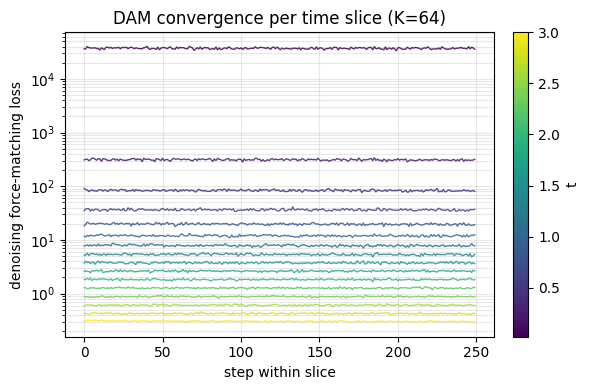

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.0))
cmap = plt.cm.viridis
n_slices = len(loss_history)
for idx, losses in enumerate(loss_history):
    if losses is None:
        continue
    color = cmap(idx / max(1, n_slices - 1))
    ax.plot(losses, color=color, alpha=0.85, linewidth=1.0)
ax.set_xlabel("step within slice")
ax.set_ylabel("denoising force-matching loss")
ax.set_yscale("log")
ax.set_title(f"DAM convergence per time slice (K={K_DEFAULT})")
ax.grid(alpha=0.3, which="both")
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=float(TIME_GRID[0]),
                                              vmax=float(TIME_GRID[-1])))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("t")
plt.tight_layout()
plt.show()

## Reverse-time sampling

Integrate the reverse OU SDE
$$dx \\;=\\; [\\,x + 2 f_\\theta(x, s)\\,]\\,dr \\;+\\; \\sqrt{2 k_BT}\\,dw, \\qquad s = \\tau - r,$$
from $x \\sim \\mathcal N(0, k_BT I)$ at $r = 0$ down to $s = T_{\\min}$ at $r = \\tau$. At each step we look up the parameter set for the time slice closest to the current $s$.

The whole rollout is wrapped in `jax.lax.scan` over a pre-baked stack of per-slice parameters so it stays on-device.

In [11]:
def stack_params(params_seq):
    """Convert a list of {c, b} per slice into stacked arrays for indexing."""
    cs = jnp.stack([p["c"] for p in params_seq], axis=0)
    bs = jnp.stack([p["b"] for p in params_seq], axis=0)
    return {"c": cs, "b": bs}


def build_schedule(n_steps, t_grid, tau, t_min):
    """Pre-compute the (s, slice_idx, a_t, sigma2) tuple at each reverse step."""
    dt = tau / n_steps
    ss = jnp.maximum(t_min, tau - jnp.arange(n_steps) * dt)
    a_s = jnp.exp(-ss)
    sigma2_s = jnp.maximum(1e-6, 1.0 * (1.0 - a_s ** 2))  # kBT = 1
    # nearest-slice index for each step
    diffs = jnp.abs(ss[:, None] - t_grid[None, :])
    slice_idx = jnp.argmin(diffs, axis=1).astype(jnp.int32)
    return dt, ss, a_s, sigma2_s, slice_idx


@partial(jax.jit, static_argnames=("n_steps", "n_samples", "clip_x"))
def reverse_sample_dam(key, stacked_params, t_grid_arr, n_samples, n_steps,
                       tau=TAU, t_min=T_MIN, kBT_val=kBT, clip_x=6.0):
    key, k_init = random.split(key)
    d = stacked_params["c"].shape[-1]
    x0 = jnp.sqrt(kBT_val) * random.normal(k_init, (n_samples, d))
    dt, ss, a_s, sigma2_s, slice_idx = build_schedule(n_steps, t_grid_arr, tau, t_min)

    def body(carry, step_inputs):
        x, key = carry
        a_t, sigma2, idx = step_inputs
        params_t = {"c": stacked_params["c"][idx], "b": stacked_params["b"][idx]}
        f = dam_force_analytic(params_t, x, a_t, sigma2)
        key, k_noise = random.split(key)
        noise = random.normal(k_noise, x.shape)
        x_new = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT_val * dt) * noise
        x_new = jnp.clip(x_new, -clip_x, clip_x)
        return (x_new, key), x_new

    (x_final, key), _ = jax.lax.scan(body, (x0, key), (a_s, sigma2_s, slice_idx))
    return x_final, key


stacked = stack_params(params_seq)
key, sub = random.split(key)
samples, key = reverse_sample_dam(sub, stacked, TIME_GRID, n_samples=N_SAMPLES,
                                  n_steps=N_REVERSE_STEPS)
print("samples shape:", samples.shape)

samples shape: (64, 784)


## Visualise: training data, learned prototypes, generated samples

Three grids of `IMG_SIDE × IMG_SIDE` images.
- **Training data** (top): a fresh random batch of the training set, for comparison.
- **Prototypes at $t = T_{\min}$** (middle): the $K$ memory vectors $c_a$ from the smallest-noise slice. After training these should look like clean digits, possibly with structured combinations.
- **Generated samples** (bottom): the output of the reverse SDE from Gaussian noise. These should look like 0s and 1s; if they look like one prototype repeated, the sampler has collapsed and the K-sweep below should reveal it.

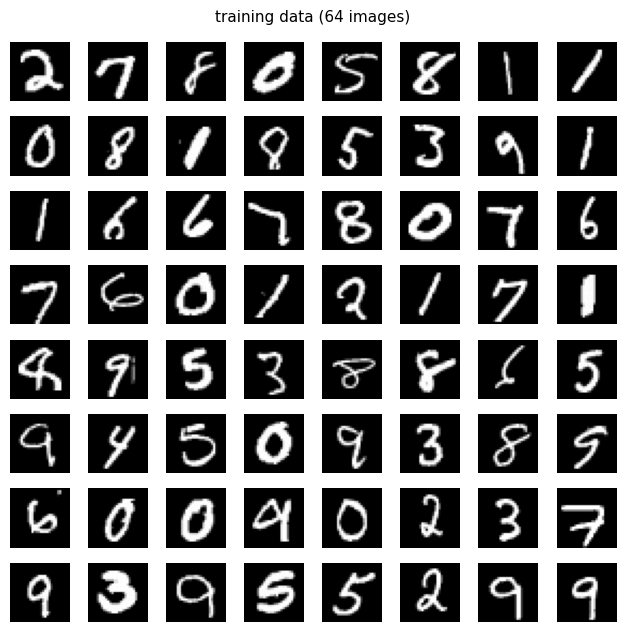

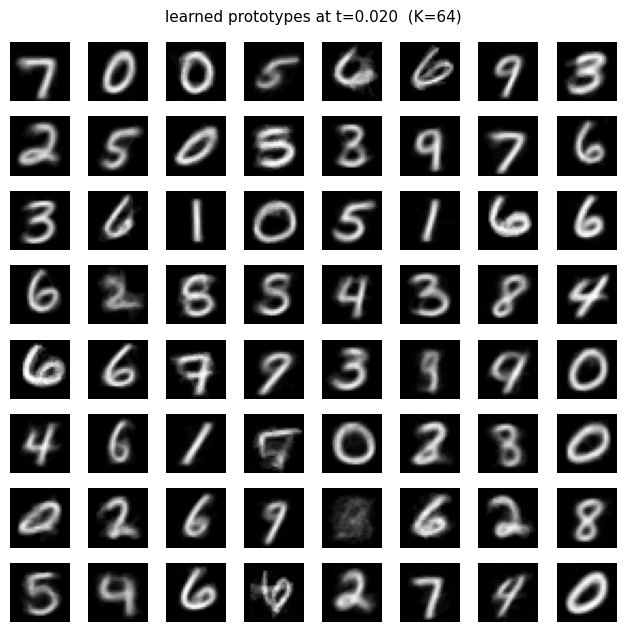

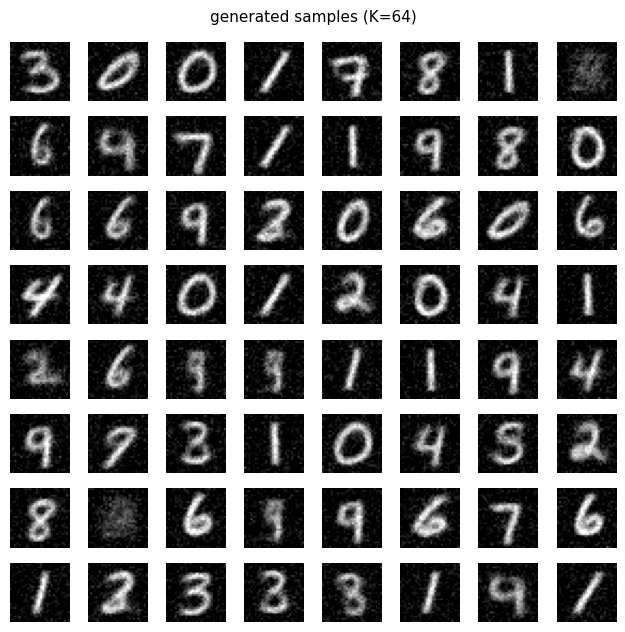

In [12]:
def show_image_grid(arr_flat, title, n_show=64, n_cols=8, vmin=-1, vmax=1):
    n = min(n_show, arr_flat.shape[0])
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 0.8, n_rows * 0.8))
    axes = np.atleast_2d(axes)
    for i in range(n_rows * n_cols):
        ax = axes.ravel()[i]
        if i < n:
            img = np.asarray(arr_flat[i]).reshape(IMG_SIDE, IMG_SIDE)
            ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
        ax.axis("off")
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# Training data sample.
key, ksh = random.split(key)
idx = random.randint(ksh, (N_SAMPLES,), 0, train_data.shape[0])
show_image_grid(train_data[idx], f"training data ({N_SAMPLES} images)")

# Learned prototypes at the smallest-noise slice.
protos = params_seq[0]["c"]
show_image_grid(protos, f"learned prototypes at t={float(TIME_GRID[0]):.3f}  (K={K_DEFAULT})")

# Generated samples.
show_image_grid(samples, f"generated samples (K={K_DEFAULT})")

## Memorisation diagnostics

§13.3 of the note lists *nearest-neighbour memorisation* and *spurious-state rate* as the two evaluation metrics for a DenseAM-on-MNIST run. We compute:

1. **Sample → nearest training image distance**: pixel-space L2 distance from each generated sample to its nearest training point. Compared with the distribution of training point → second-nearest training point distances (a control for the intrinsic dataset density). If sample distances are systematically *smaller* than the control distribution, the model has memorised; if they sit at the control level, it is generalising within the data manifold; if they are systematically larger, the samples are off-manifold.
2. **Sample → nearest prototype distance**: do generated samples land near learned prototypes, or do they interpolate between them? A heavily memorising DAM produces samples that pile onto individual prototypes.
3. **Predicted-digit histogram**: for each generated sample, classify it as the digit class of its nearest training point. Tests whether both digit classes are produced or only one is recovered.

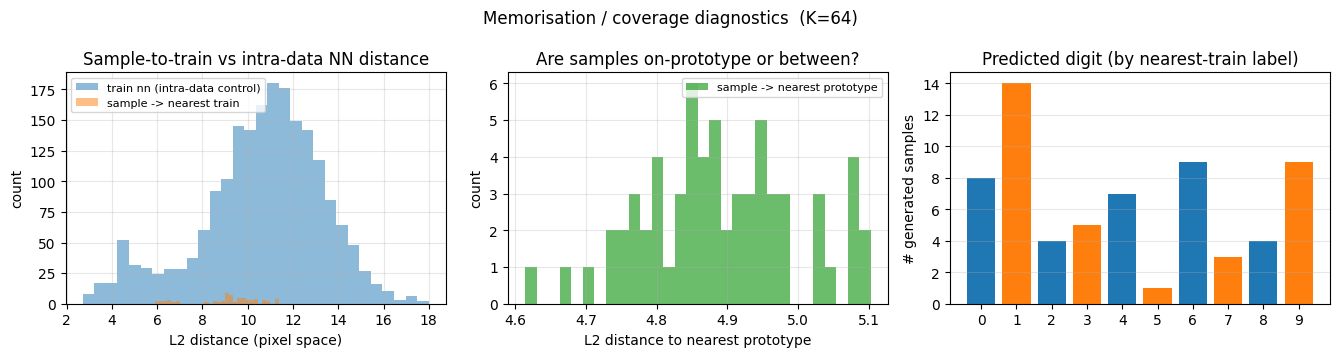

Summary:
  median d(sample -> nearest train) = 9.305
  median d(sample -> nearest proto) = 4.879
  median d(train -> nearest train) = 10.928  (control)
  digit counts: {'0': 8, '1': 14, '2': 4, '3': 5, '4': 7, '5': 1, '6': 9, '7': 3, '8': 4, '9': 9}


In [13]:
def pairwise_l2(a, b, block=512):
    """L2 distance from each row of a to each row of b, computed in blocks
    of a to keep memory bounded. Returns a numpy array of shape (na, nb)."""
    a = np.asarray(a)
    b = np.asarray(b)
    out = np.empty((a.shape[0], b.shape[0]), dtype=np.float32)
    bn = (b ** 2).sum(axis=1)
    for i in range(0, a.shape[0], block):
        ai = a[i:i + block]
        an = (ai ** 2).sum(axis=1, keepdims=True)
        d2 = an + bn[None, :] - 2.0 * ai @ b.T
        out[i:i + block] = np.sqrt(np.maximum(d2, 0.0))
    return out


def nn_diagnostics(samples_x, train_x, train_y, prototypes):
    """Return dict of memorisation diagnostics."""
    samples_np = np.asarray(samples_x)
    train_np = np.asarray(train_x)
    proto_np = np.asarray(prototypes)

    # Sample -> nearest training image.
    d_st = pairwise_l2(samples_np, train_np)
    nn_idx = d_st.argmin(axis=1)
    d_sample_to_train = d_st.min(axis=1)
    pred_digits = np.asarray(train_y)[nn_idx]

    # Sample -> nearest prototype.
    d_sp = pairwise_l2(samples_np, proto_np)
    d_sample_to_proto = d_sp.min(axis=1)

    # Training -> second-nearest training (control: typical inter-data distance).
    d_tt = pairwise_l2(train_np, train_np)
    np.fill_diagonal(d_tt, np.inf)
    d_train_to_train = d_tt.min(axis=1)

    return {
        "d_sample_to_train": d_sample_to_train,
        "d_sample_to_proto": d_sample_to_proto,
        "d_train_to_train": d_train_to_train,
        "pred_digits": pred_digits,
        "nearest_train_idx": nn_idx,
    }


diag = nn_diagnostics(samples, train_data, train_labels, params_seq[0]["c"])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))

ax = axes[0]
ax.hist(diag["d_train_to_train"], bins=30, alpha=0.5, label="train nn (intra-data control)")
ax.hist(diag["d_sample_to_train"], bins=30, alpha=0.5, label="sample -> nearest train")
ax.set_xlabel("L2 distance (pixel space)")
ax.set_ylabel("count")
ax.set_title("Sample-to-train vs intra-data NN distance")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(diag["d_sample_to_proto"], bins=30, alpha=0.7, color="C2",
        label="sample -> nearest prototype")
ax.set_xlabel("L2 distance to nearest prototype")
ax.set_ylabel("count")
ax.set_title("Are samples on-prototype or between?")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
labels_uniq = sorted(set(int(x) for x in DIGITS))
counts = [int(np.sum(diag["pred_digits"] == d)) for d in labels_uniq]
ax.bar([str(d) for d in labels_uniq], counts, color=["C0", "C1"][: len(labels_uniq)])
ax.set_ylabel("# generated samples")
ax.set_title("Predicted digit (by nearest-train label)")
ax.grid(alpha=0.3, axis="y")

plt.suptitle(f"Memorisation / coverage diagnostics  (K={K_DEFAULT})")
plt.tight_layout()
plt.show()

print("Summary:")
print(f"  median d(sample -> nearest train) = {np.median(diag['d_sample_to_train']):.3f}")
print(f"  median d(sample -> nearest proto) = {np.median(diag['d_sample_to_proto']):.3f}")
print(f"  median d(train -> nearest train) = {np.median(diag['d_train_to_train']):.3f}  (control)")
print(f"  digit counts: {dict(zip([str(d) for d in labels_uniq], counts))}")

## Side-by-side: each generated sample next to its nearest training neighbour

A direct visual memorisation test. If the model has memorised, every row should show two identical-looking digits. If it has generalised, the sample looks like a 0 or 1 but is not the literal nearest training point.

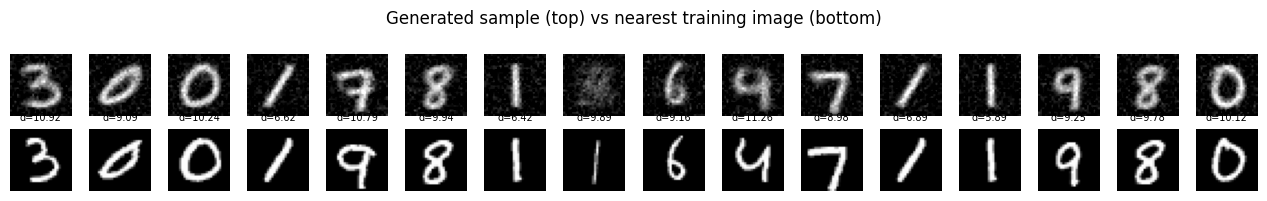

In [14]:
n_pairs = 16
fig, axes = plt.subplots(2, n_pairs, figsize=(n_pairs * 0.8, 2.0))
for i in range(n_pairs):
    sample_img = np.asarray(samples[i]).reshape(IMG_SIDE, IMG_SIDE)
    nn_img = np.asarray(train_data[diag["nearest_train_idx"][i]]).reshape(IMG_SIDE, IMG_SIDE)
    axes[0, i].imshow(sample_img, cmap="gray", vmin=-1, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(nn_img, cmap="gray", vmin=-1, vmax=1)
    axes[1, i].axis("off")
    axes[1, i].set_title(f"d={diag['d_sample_to_train'][i]:.2f}", fontsize=7)
axes[0, 0].set_ylabel("sample", rotation=0, ha="right", va="center")
axes[1, 0].set_ylabel("nearest train", rotation=0, ha="right", va="center")
plt.suptitle("Generated sample (top) vs nearest training image (bottom)")
plt.tight_layout()
plt.show()

## $K$-sweep: prototype count vs sample quality

§13.3 of the note specifies the sweep $K \\in \\{16, 32, 64, 128, 256\\}$. We omit $K=256$ from the default run because it dominates wall time in the non-research configuration; flip `RESEARCH_MODE = True` at the top of the notebook to include it.

The note's §9.2 prediction is that small $K$ should under-fit (samples are dispersed; high nearest-train distance), intermediate $K$ should generalise (samples look like data without being copies), and very large $K$ should over-memorise (samples collapse onto specific training points; $d(\\text{sample}\\to\\text{nearest train})$ becomes much smaller than the intra-data control). The plot below pulls out the median of each diagnostic so the trend is visible at a glance.

In [15]:
K_LIST = [16, 32, 64, 128, 256] if RESEARCH_MODE else [16, 32, 64, 128]

sweep = {}
for K in K_LIST:
    print(f"\
--- training DAM with K = {K} ---")
    key, sub = random.split(key)
    ps, lh, key = train_dam_schedule(sub, train_data, K, TIME_GRID, verbose=False)
    stacked_K = stack_params(ps)
    key, sub = random.split(key)
    sx, key = reverse_sample_dam(sub, stacked_K, TIME_GRID,
                                 n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS)
    d = nn_diagnostics(sx, train_data, train_labels, ps[0]["c"])
    sweep[K] = {"params": ps, "samples": sx, "diag": d, "loss_history": lh}
    print(f"  median d(sample->train) = {np.median(d['d_sample_to_train']):.3f} "
          f"| d(sample->proto) = {np.median(d['d_sample_to_proto']):.3f} "
          f"| digit counts = {dict(zip([str(x) for x in DIGITS], [int(np.sum(d['pred_digits']==x)) for x in DIGITS]))}")

--- training DAM with K = 16 ---
  median d(sample->train) = 9.877 | d(sample->proto) = 4.883 | digit counts = {'0': 8, '1': 7, '2': 1, '3': 9, '4': 3, '5': 4, '6': 4, '7': 10, '8': 1, '9': 17}
--- training DAM with K = 32 ---
  median d(sample->train) = 10.218 | d(sample->proto) = 4.869 | digit counts = {'0': 7, '1': 12, '2': 4, '3': 5, '4': 4, '5': 9, '6': 4, '7': 7, '8': 5, '9': 7}
--- training DAM with K = 64 ---
  median d(sample->train) = 9.359 | d(sample->proto) = 4.862 | digit counts = {'0': 7, '1': 17, '2': 4, '3': 6, '4': 7, '5': 5, '6': 7, '7': 2, '8': 5, '9': 4}
--- training DAM with K = 128 ---
  median d(sample->train) = 9.471 | d(sample->proto) = 4.864 | digit counts = {'0': 7, '1': 7, '2': 3, '3': 5, '4': 8, '5': 6, '6': 13, '7': 4, '8': 4, '9': 7}


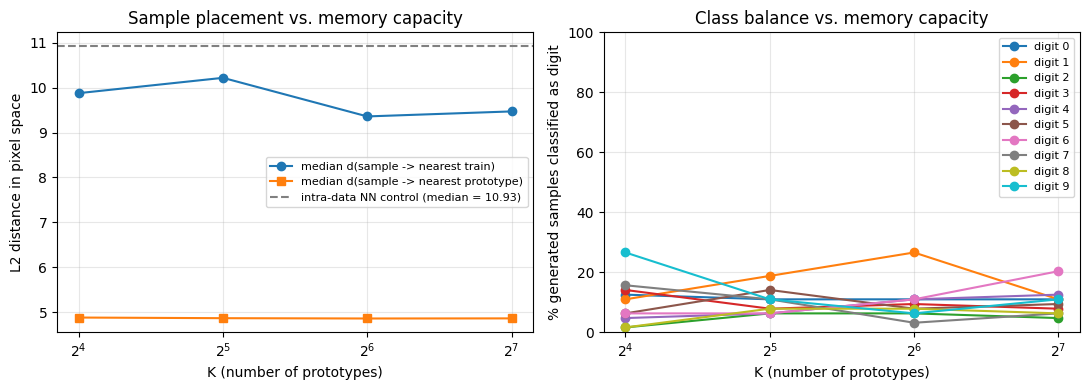

In [16]:
# Aggregate K-sweep statistics into a single panel.
Ks = sorted(sweep.keys())
med_train = [float(np.median(sweep[K]["diag"]["d_sample_to_train"])) for K in Ks]
med_proto = [float(np.median(sweep[K]["diag"]["d_sample_to_proto"])) for K in Ks]
control = float(np.median(sweep[Ks[0]]["diag"]["d_train_to_train"]))  # K-independent

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
ax = axes[0]
ax.plot(Ks, med_train, marker="o", label="median d(sample -> nearest train)")
ax.plot(Ks, med_proto, marker="s", label="median d(sample -> nearest prototype)")
ax.axhline(control, color="grey", linestyle="--",
           label=f"intra-data NN control (median = {control:.2f})")
ax.set_xscale("log", base=2)
ax.set_xlabel("K (number of prototypes)")
ax.set_ylabel("L2 distance in pixel space")
ax.set_title("Sample placement vs. memory capacity")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

ax = axes[1]
digit_pcts = {d: [] for d in DIGITS}
for K in Ks:
    preds = sweep[K]["diag"]["pred_digits"]
    for d in DIGITS:
        digit_pcts[d].append(100.0 * np.mean(preds == d))
for d in DIGITS:
    ax.plot(Ks, digit_pcts[d], marker="o", label=f"digit {d}")
ax.set_xscale("log", base=2)
ax.set_xlabel("K (number of prototypes)")
ax.set_ylabel("% generated samples classified as digit")
ax.set_title("Class balance vs. memory capacity")
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

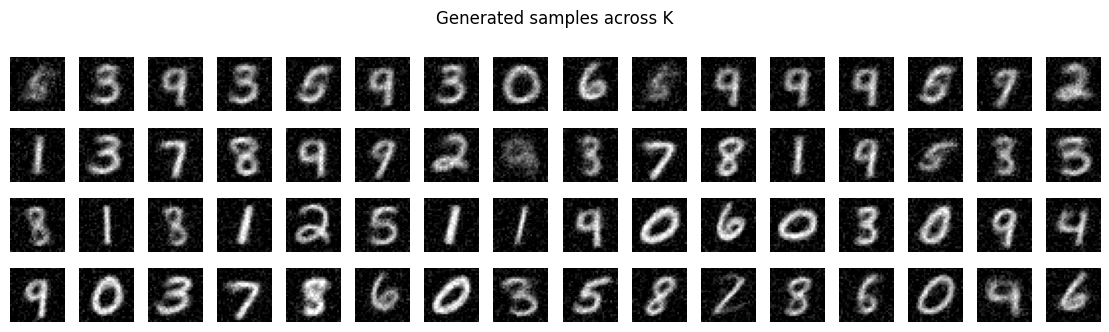

In [17]:
# Visualise generated samples from each K in the sweep, on a common grid.
n_per_K = 16
fig, axes = plt.subplots(len(Ks), n_per_K, figsize=(n_per_K * 0.7, len(Ks) * 0.85))
for row, K in enumerate(Ks):
    sx = sweep[K]["samples"]
    for j in range(n_per_K):
        ax = axes[row, j] if len(Ks) > 1 else axes[j]
        ax.imshow(np.asarray(sx[j]).reshape(IMG_SIDE, IMG_SIDE),
                  cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
    ax_first = axes[row, 0] if len(Ks) > 1 else axes[0]
    ax_first.set_ylabel(f"K={K}", rotation=0, ha="right", va="center", fontsize=10)
plt.suptitle("Generated samples across K")
plt.tight_layout()
plt.show()

## Interpretation checklist

What to read off this notebook, in order:

1. **Gradient check.** Analytic and autodiff DAM forces must match to ~floating-point precision at every test $t$. The drift-aware logits are a non-trivial change relative to the 2D version, so this re-check is the first guard against a derivation bug.
2. **Convergence per slice.** Each line should flatten within `STEPS_PER_TIME`. If the small-$t$ slices are still descending at the end, you are under-trained — raise `STEPS_PER_TIME` or `RESEARCH_MODE = True`. If the small-$t$ slices flatten *much* higher than the large-$t$ slices, the model is capacity-limited and a larger $K$ should help.
3. **Samples vs. training data.** Visually: the generated grid should contain a mixture of 0s and 1s with strokes of comparable thickness to the training set. If samples are blurry/grey, the sampler hasn't sharpened (check `T_MIN`, `N_REVERSE_STEPS`); if all samples are the same digit, mode collapse has occurred (and the K-sweep should show whether this is capacity-related).
4. **Memorisation histograms.** The decisive plot. With the prototype count well-matched to the data manifold, the `sample → nearest train` distribution should overlap the `train → nearest train` control. If it sits noticeably lower, the model has memorised; if it sits noticeably higher, samples are off-manifold.
5. **Sample-vs-NN pairs.** Visual confirmation of point 4 for individual samples.
6. **$K$-sweep.** Sample-to-train distance is the principal scalar diagnostic — it should be U-shaped or monotonically decreasing in $K$ depending on whether the data manifold is over- or under-parameterised at the largest tested $K$. The class-balance panel should stay near 50/50 for all $K$; persistent skew signals that the noise schedule or reverse sampler is not mixing across modes.

**Hardware-track follow-ups (note §13.4) that this notebook is set up for.** Replace `dam_force_analytic` by a quantised crossbar emulator (uniform conductance quantisation, fixed dynamic range, additive read noise), or by a version that uses the *frozen-hidden* update $\\Delta c_a \\approx \\eta\\, r_a\\, \\delta/\\sigma_t^2$ from eq. (40) of the note — both can be slotted into `dam_loss` and trained with the existing schedule for direct comparison against the autodiff baseline.